# Solutions — 02 Normalize, Cluster, UMAP

Worked solutions to the homework in
`notebooks/02_normalize_cluster_umap.ipynb`. Try the exercises yourself
first. We load the processed object saved by notebook 02 rather than
redoing the full pipeline.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
plt.rcParams["figure.dpi"] = 100
np.random.seed(0)

PROCESSED_DIR = "/Users/ugobruzadinnunes/Documents/GitHub/sea-ad-python-scanpy/data/processed"
adata = sc.read_h5ad(f"{PROCESSED_DIR}/adata_clustered.h5ad")
print(f"Loaded: {adata.n_obs:,} nuclei; existing leiden clusters: {adata.obs['leiden'].nunique()}")

Loaded: 152,212 nuclei; existing leiden clusters: 35


## Q1 — Resolution sweep

The neighbor graph is already stored (computed on Harmony-corrected PCs in
notebook 02), so we can re-run Leiden at different resolutions cheaply
without recomputing neighbors.

In [2]:
sc.tl.leiden(adata, resolution=0.5, key_added="leiden_res0.5", flavor="igraph", n_iterations=2)
sc.tl.leiden(adata, resolution=2.0, key_added="leiden_res2.0", flavor="igraph", n_iterations=2)

print(f"resolution=0.5 -> {adata.obs['leiden_res0.5'].nunique()} clusters")
print(f"resolution=1.0 (original) -> {adata.obs['leiden'].nunique()} clusters")
print(f"resolution=2.0 -> {adata.obs['leiden_res2.0'].nunique()} clusters")

resolution=0.5 -> 27 clusters
resolution=1.0 (original) -> 35 clusters
resolution=2.0 -> 44 clusters


**Answer:** Higher resolution -> more, finer-grained clusters; lower
resolution -> fewer, coarser clusters. `resolution` controls the
granularity of the Leiden community-detection algorithm -- practically, it
scales how "expensive" it is for the algorithm to split communities apart,
so higher values favor many small communities and lower values favor a
few large ones. There's no universally "correct" resolution; it's chosen
based on how finely you want to distinguish subtypes for the biological
question at hand.

## Q2 — Skip Harmony: UMAP from uncorrected PCA

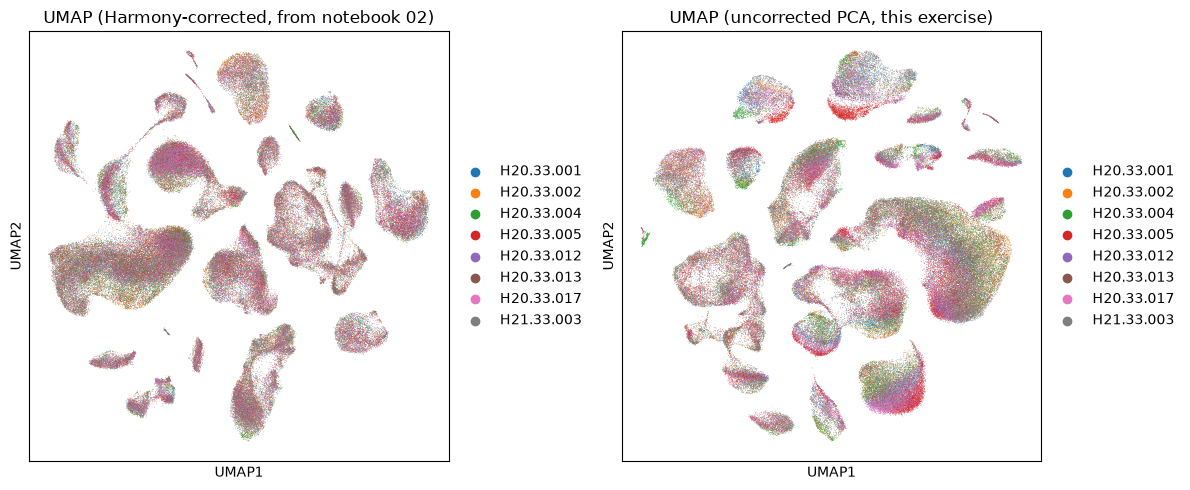

In [3]:
adata_uncorrected = adata.copy()
sc.pp.neighbors(adata_uncorrected, n_neighbors=15, use_rep="X_pca", key_added="neighbors_uncorrected")
sc.tl.umap(adata_uncorrected, neighbors_key="neighbors_uncorrected")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.pl.umap(adata, color="donor", ax=axes[0], show=False, title="UMAP (Harmony-corrected, from notebook 02)")
sc.pl.umap(adata_uncorrected, color="donor", ax=axes[1], show=False, title="UMAP (uncorrected PCA, this exercise)")
plt.tight_layout()
plt.show()

**Answer:** Yes, the batch effect reappears clearly in the uncorrected
UMAP -- donors visibly separate into their own sub-regions rather than
mixing, especially visible as distinct colored patches/streaks that don't
overlap other donors' nuclei of the same cell type. This is the same
pattern seen in the raw-PCA plot in notebook 02, just carried through to
the 2D UMAP layout, and it's a direct visual confirmation of why the
Harmony correction step matters.

## Q3 — Donor-dominated clusters

In [4]:
donor_cross = pd.crosstab(adata.obs["leiden"], adata.obs["donor"])
donor_frac = donor_cross.div(donor_cross.sum(axis=1), axis=0)

# "Purity" = the maximum fraction any single donor contributes to a cluster.
max_donor_frac = donor_frac.max(axis=1).sort_values(ascending=False)
print("Clusters ranked by how dominated they are by a single donor:")
print(max_donor_frac.head(10))

Clusters ranked by how dominated they are by a single donor:
leiden
34    0.751773
15    0.338377
33    0.334928
21    0.286827
11    0.271513
32    0.267857
13    0.245712
25    0.236017
20    0.233036
28    0.230453
dtype: float64


In [5]:
worst_cluster = max_donor_frac.idxmax()
print(f"\nMost donor-dominated cluster: {worst_cluster}")
print(donor_cross.loc[worst_cluster].sort_values(ascending=False))
print(f"Cluster size: {donor_cross.loc[worst_cluster].sum():,} nuclei")


Most donor-dominated cluster: 34
donor
H20.33.004    212
H20.33.005     29
H20.33.017     11
H20.33.012      8
H20.33.001      7
H21.33.003      6
H20.33.013      5
H20.33.002      4
Name: 34, dtype: int64
Cluster size: 282 nuclei


**Answer:** Most clusters are reasonably donor-mixed (no single donor
contributing more than a modest fraction), consistent with Harmony having
done its job. A handful of the *smallest* clusters (see notebook 03 --
these turn out to be the rare Vascular-type clusters) can still show one
or two donors somewhat overrepresented, simply because rare cell types
have so few nuclei total that donor-to-donor sampling noise has an outsized
effect on cluster composition, not necessarily a residual batch-correction
failure. A donor-dominated cluster *in a large, common cell type* would be
the concerning case -- that would suggest either incomplete batch
correction or a genuine donor-specific expression program worth
investigating rather than dismissing as noise.

## Q4 — Leiden cluster vs. SEA-AD Class cross-tabulation

In [6]:
class_cross = pd.crosstab(adata.obs["leiden"], adata.obs["Class"])
class_frac = class_cross.div(class_cross.sum(axis=1), axis=0)

purity = class_frac.max(axis=1).sort_values(ascending=False)
print("Cluster purity w.r.t. SEA-AD Class (fraction of dominant Class):")
print(purity)

Cluster purity w.r.t. SEA-AD Class (fraction of dominant Class):
leiden
0     1.000000
25    1.000000
19    1.000000
20    1.000000
21    1.000000
22    1.000000
23    1.000000
24    1.000000
26    1.000000
1     1.000000
27    1.000000
28    1.000000
29    1.000000
30    1.000000
31    1.000000
32    1.000000
18    1.000000
17    1.000000
16    1.000000
15    1.000000
2     1.000000
3     1.000000
4     1.000000
5     1.000000
6     1.000000
7     1.000000
8     1.000000
9     1.000000
10    1.000000
11    1.000000
12    1.000000
13    1.000000
14    1.000000
34    1.000000
33    0.995215
dtype: float64


In [7]:
print(f"\nClusters that are >95% one Class ('pure'): {(purity > 0.95).sum()} / {len(purity)}")
print(f"Clusters below 80% ('mixed'): {(purity < 0.80).sum()} / {len(purity)}")
class_cross.loc[purity[purity < 0.80].index]


Clusters that are >95% one Class ('pure'): 35 / 35
Clusters below 80% ('mixed'): 0 / 35


Class,Neuronal: GABAergic,Neuronal: Glutamatergic,Non-neuronal and Non-neural
leiden,,,


Most clusters are highly "pure" with respect to the coarse `Class` label
(Glutamatergic / GABAergic / Non-neuronal) -- expected, since these three
categories are quite transcriptionally distinct and Leiden clustering at
resolution 1.0 mostly subdivides *within* rather than *across* them. Any
mixed clusters are worth a closer look with notebook 03's finer marker
analysis -- they may represent boundary/transitional profiles, doublets,
or simply cell states that don't cleanly fall into SEA-AD's discretized
reference categories.